# IMDB & TMDB: DataSet de informacion general de peliculas y series de todo el mundo.

El primer paso sera instalar todas las librerias necesarias solamente una unica vez y despues de instalarlas deberemos de cargarlas en el sistema.

In [ ]:
# ============================================
# INSTALACIÓN Y CARGA DE LIBRERÍAS
# ============================================

# Instalar librerías necesarias (solo la primera vez)
install.packages(c("tidyverse", "ggplot2", "dplyr", "readr",
                   "stringr", "lubridate", "scales", "corrplot",
                   "skimr", "DataExplorer", "gridExtra"))

# Cargar librerías
library(tidyverse)
library(ggplot2)
library(dplyr)
library(readr)
library(stringr)
library(lubridate)
library(scales)
library(corrplot)
library(skimr)
library(gridExtra)

cat("✅ Librerías cargadas correctamente\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘data.tree’, ‘igraph’, ‘reshape2’, ‘networkD3’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




✅ Librerías cargadas correctamente


El segundo paso seria importar nuestro DataSet.

In [ ]:
# ============================================
# IMPORTAR EL DATASET
# ============================================

# Leer el dataset con el nombre correcto
movies <- read_csv("IMDB TMDB Movie Metadata Big Dataset (1M).csv",
                   show_col_types = FALSE,
                   n_max = 100000)  # Limita a 100k filas para mejor rendimiento

cat("✅ Dataset cargado correctamente\n")
cat(paste("Dimensiones:", nrow(movies), "filas x", ncol(movies), "columnas\n"))

✅ Dataset cargado correctamente
Dimensiones: 100000 filas x 42 columnas


Una vez que ya tenemos nuestro DataSet importado haremos una pequeña exploracion inicial de este.

In [ ]:
# ============================================
# EXPLORACIÓN INICIAL DEL DATASET
# ============================================

# 1. Ver las primeras filas
cat("========== PRIMERAS 5 FILAS ==========\n")
head(movies, 5)

# 2. Ver las últimas filas
cat("\n========== ÚLTIMAS 5 FILAS ==========\n")
tail(movies, 5)

# 3. Estructura del dataset
cat("\n========== ESTRUCTURA DEL DATASET ==========\n")
str(movies)

# 4. Nombres de todas las columnas
cat("\n========== NOMBRES DE COLUMNAS ==========\n")
names(movies)

# 5. Dimensiones
cat("\n========== DIMENSIONES ==========\n")
cat(paste("Número de filas:", nrow(movies), "\n"))
cat(paste("Número de columnas:", ncol(movies), "\n"))

========== PRIMERAS 5 FILAS ==========


id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,⋯,Star3,Star4,Writer,Director_of_Photography,Producers,Music_Composer,genres_list,Cast_list,overview_sentiment,all_combined_keywords
<dbl>,<chr>,<dbl>,<dbl>,<chr>,<date>,<dbl>,<dbl>,<lgl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,FALSE,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,⋯,Elliot Page,Ken Watanabe,Christopher Nolan,Wally Pfister,"Thomas Tull, Christopher Nolan, Chris Brigham, Emma Thomas, Kanjirô Sakura, Yoshikuni Taki",Hans Zimmer,"['Action', 'Science Fiction', 'Adventure']","['Tim Kelleher', 'Silvie Laguna', 'Natasha Beaumont', 'Kraig Thornber', 'Jack Murray', 'Adam Cole', 'Claire Geare', 'Marion Cotillard', 'Magnus Nolan', 'Tai-Li Lee', 'Shannon Welles', 'Taylor Geare', 'Tom Berenger', 'Coralie Dedykere', 'Carl Gilliard', 'Miranda Nolan', 'Earl Cameron', 'Yuji Okumoto', 'Helena Cullinan', 'Nicolas Clerc', 'Andrew Pleavin', 'Alex Lombard', 'Mark Fleischmann', 'Michael Gaston', 'Marc Raducci', 'Jack Gilroy', 'Nicole Pulliam', 'Shelley Lang', 'Lukas Haas', 'Russ Fega', 'Felix Scott', 'Ryan Hayward', 'Cillian Murphy', 'Dileep Rao', 'Jill Maddrell', 'Jean-Michel Dagory', 'Jason Tendell', 'Virgile Bramly', 'Tom Hardy', 'Tohoru Masamune', 'Michael Caine', 'Talulah Riley', 'Angela Nathenson', 'Lisa Reynolds', 'Peter Basham', 'Daniel Girondeaud', 'Johnathan Geare', 'Pete Postlethwaite']",-0.01111111,"['s', 'philosophy', 'skilled', 'kidnapping', 'manipulation', 'mission', 'person', ""target 's subconscious"", 'implantation', 'rescue', 'infiltrating', 'corporate espionage', 'life', 'architecture', 'thief', 'chance', 'cobb', 'impossible', 'task', 'dream', 'payment', 'corporate', 'inception', 'spy', 'considered', 'heist', 'california', 'regain', 'old life', 'subconscious', 'france', 'paris', 'idea', 'target', 'offered', ""person 's idea"", 'allegory', 'airplane', 'old', 'espionage', 'skilled thief', 'memory', 'virtual reality', 'car crash', 'los angeles', 'commits', 'targets', 'dream world']"
157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,FALSE,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,⋯,Jessica Chastain,Mackenzie Foy,Jonathan Nolan,Hoyte van Hoytema,"Jake Myers, Emma Thomas, Jordan Goldberg, Thomas Tull, Lynda Obst, Christopher Nolan, Kip Thorne",Hans Zimmer,"['Adventure', 'Drama', 'Science Fiction']","['Jeff Hephner', 'William Devane', 'Elyes Gabel', 'Topher Grace', 'Lena Georgas', 'Russ Fega', 'Alexander Michael Helisek', 'Benjamin Hardy', 'Michael Caine', 'Liam Dickinson', 'Collette Wolfe', 'Flora Nolan', 'Griffen Fraser', 'Kristian Van der Heyden', 'Ellen Burstyn', 'John Lithgow', 'Francis X. McCarthy', 'Timothée Chalamet', 'Casey Affleck', 'Bill Irwin', 'Leah Cairns', 'Brooke Smith', 'William Patrick Brown', 'David Gyasi', 'Josh Stewart', 'Wes Bentley', 'Andrew Borba', 'Ryan Irving', 'Matt Damon', 'David Oyelowo', 'Joseph Oliveira']",0.04545455,"['thoughtful', 'use', 'scientist', 'quantum mechanics', 'time-manipulation', 'farmer', 'human space travel', 'time manipulation', 'interstellar voyage', '2060s', 'conquer', 'rescue', 'race against time', 'space', 'distances', 'surpass', 'wormhole', 'expedition', 'space station', 'involved', 'father daughter relationship', 'limitations', 'explorers', 'make', 'adventures', 'group', 'nasa', 'interstellar', 'vast', 'future', 'complicated', 'vast distances', 'astronaut', 'cornfield', 'single father', 'time warp', 'voyage', 'discovered', 'dystopia', 'black hole', 'famine', 'space adventure', 'newly', 'family relationships', 'time paradox', 'human', 'travel', 'artificial intelligence (a.i.)', 'curious', 'space travel', 'robot', 'spacecraft']"
155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,FALSE,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,⋯,Aaron Eckhart,Michael Caine,Jonathan Nolan,Wally Pfister,"Kevin De La Noy, Thomas Tull, Christopher Nolan, Emma Thomas, Michael Uslan, Charles Roven, Benjamin Melniker","


========== ÚLTIMAS 5 FILAS ==========


id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,⋯,Star3,Star4,Writer,Director_of_Photography,Producers,Music_Composer,genres_list,Cast_list,overview_sentiment,all_combined_keywords
<dbl>,<chr>,<dbl>,<dbl>,<chr>,<date>,<dbl>,<dbl>,<lgl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
781801,Steve McQueen: The Lost Movie,7.2,6,Released,2021-01-01,0,87,FALSE,/3aJinGYBeofF8r7KYqAUav3KriO.jpg,⋯,NA,NA,Kikumi Yamagishi,Nobuyasu Kita,"Nobuyuki Tanizawa, Kensuke Zushi, Yi-Wan Ren, Toshiaki Nakazawa, Toshiaki Okuno, Hengameh Panahi, Naoya Kinoshita, Nobuyuki Tohya, Misako Saka, Shigeyuki Endō",Koji Endo,['Documentary'],"['Ichikawa Ebizo XI', 'Miho Nakanishi', 'Hideaki Ito', 'Maiko', 'Toshiaki Karasawa', 'Ikko Furuya', 'Hiroshi Katsuno', 'Koichi Sato', 'Kenichi Hagiwara', 'Hitomi Katayama', 'Toshie Negishi', 'Ko Shibasaki']",0.00000000,"['film', 'motor racing', 'champion', 'story', 'formula', 'day', '1', 'formula one (f1)', 'film history', 'sports', 'production', 'abandoned', 'movie', 'set', '1966']"
381786,Anna's Life,6.0,6,Released,2017-06-16,0,108,FALSE,NA,⋯,NA,NA,"Sergei Dvortsevoy, Gennadiy Ostrovskiy",Jolanta Dylewska,"Sergei Dvortsevoy, Thanassis Karathanos, Anna Wydra, Martin Hampel, Svetlana Zimagorova",NA,['Drama'],"['Andrey Kolyadov', 'Nurzhan Kunnazarova', 'Azamat Satimbaev', 'Sergey Mazur', 'Dzhipargul Abdilova', 'Alexandr Zlatopolsky', 'Cholponay Borubaeva', 'Askhat Kuchencherekov', 'Larisa Firsova', 'Samal Yeslyamova', 'Polina Severnaya', 'David Alaverdyan']",-0.16785714,"['s', 'lives', 'getting', 'tickets', 'children ’ s home', 'bear', 'support', 'visa', 'easier', 'fake', 'home', 'austistic', 'austistic son', 'mom', 'fake visa', 'decides', 'leave', 'jobs', 'son', 'single', 'travel', 'forced', 'said', 'anna', 'children', 'georgia']"
100594,The Book of Fate,3.5,6,Released,2003-03-06,0,85,FALSE,NA,⋯,NA,NA,Mark Morgan,"Patrice Michaux, Tiago Mesquita",NA,NA,"['Action', 'Horror', 'Science Fiction', 'Western', 'War']","['Reynald Bialès', 'Dominik Madani', 'John Flanders', 'Laurent Lesseigne', 'Gaëlle Gillis', 'Kristoffel Verdonck', 'Charlotte Beckett', 'Barry Jay Minoff', 'Gianni Capaldi', 'Lindsay Lohan', 'Peter Organ']",0.00000000,[]
328747,Une sale affaire,5.3,6,Released,1981-02-25,0,95,FALSE,NA,⋯,NA,NA,"György Pálfi, Zsófia Ruttkay",Gergely Pohárnok,"András Böhm, Csaba Bereczky",NA,"['Drama', 'Action', 'Crime']","['Ferec Bandi', 'Eszter Ónodi', 'Józsefné Rácz', 'Margitai Ági']",-0.02839506,"['includes', 'time events', 'unintentionally', 's', 'close', 'evidence', 'emotional', 'stress', ""politician 's secretary"", 'getting', 'inspector', 'police inspector', 'drug', 'destroys', 'time', 'bring', 'dealers', 'life', 'chance', 'means', 'secretary', 'events', 'end', 'especially', 'intensive emotional stress', 'help', 'corrupt politician', 'involves', 'official', 'fair', 'trial', 'home', 'methods', 'corrupt', 'politician', 'desperately', 'ring', 'needs', 'city', 'novak', 'normalcy', 'worth', 'drug dealers', 'police', 'helene', 'completed', 'home life', 'costs', 'reflect', 'intensive', 'causing', 'drug ring', 'ultimate', 'criminals', 'course', 'sister']"
168816,A Sweet Woman,4.2,6,Released,1976-06-06,0,104,FALSE,/5iJvCqqVWAljEb4h2677NKuqt7Z.jpg,⋯,NA,NA,Warren Foster,NA,Edward Selzer,Carl W. Stalling,"['Romance', 'Drama', 'Comedy']","['Bea Benaderet', 'Mel Blanc', 'Sara Berner']",0.20000000,"['life', 'big', 'young girl', 'city', 'story', 'love', 'village', 'young', 'girl', 'moves', 'anna', 'big city']"



========== ESTRUCTURA DEL DATASET ==========
spc_tbl_ [100,000 × 42] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ id                     : num [1:100000] 27205 157336 155 19995 24428 ...
 $ title                  : chr [1:100000] "Inception" "Interstellar" "The Dark Knight" "Avatar" ...
 $ vote_average           : num [1:100000] 8.36 8.42 8.51 7.57 7.71 ...
 $ vote_count             : num [1:100000] 34495 32571 30619 29815 29166 ...
 $ status                 : chr [1:100000] "Released" "Released" "Released" "Released" ...
 $ release_date           : Date[1:100000], format: "2010-07-15" "2014-11-05" ...
 $ revenue                : num [1:100000] 8.26e+08 7.02e+08 1.00e+09 2.92e+09 1.52e+09 ...
 $ runtime                : num [1:100000] 148 169 152 162 143 108 149 139 121 154 ...
 $ adult                  : logi [1:100000] FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ backdrop_path          : chr [1:100000] "/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg" "/pbrkL804c8yAv3zBZR4QPEafpAR.jpg" "/nMKdUUepR0i5z

[1] "id"                      "title"                  
 [3] "vote_average"            "vote_count"             
 [5] "status"                  "release_date"           
 [7] "revenue"                 "runtime"                
 [9] "adult"                   "backdrop_path"          
[11] "budget"                  "homepage"               
[13] "imdb_id"                 "original_language"      
[15] "original_title"          "overview"               
[17] "popularity"              "poster_path"            
[19] "tagline"                 "production_companies"   
[21] "production_countries"    "spoken_languages"       
[23] "keywords"                "release_year"           
[25] "Director"                "AverageRating"          
[27] "Poster_Link"             "Certificate"            
[29] "IMDB_Rating"             "Meta_score"             
[31] "Star1"                   "Star2"                  
[33] "Star3"                   "Star4"                  
[35] "Writer"                  "Director_of_Photography"
[37] "Producers"               "Music_Composer"         
[39] "genres_list"             "Cast_list"              
[41] "overview_sentiment"      "all_combined_keywords"


========== DIMENSIONES ==========
Número de filas: 100000 
Número de columnas: 42 


Una vez ya hemos hecho la exploracion inical del DS, el siguiente paso sera analizar los tipos de datos.

In [ ]:
# ============================================
# ANÁLISIS DE TIPOS DE DATOS
# ============================================

# Crear un dataframe con información de tipos de datos
tipos_datos <- data.frame(
  Columna = names(movies),
  Tipo = sapply(movies, class),
  Valores_Unicos = sapply(movies, function(x) length(unique(x))),
  row.names = NULL
)

cat("========== TIPOS DE DATOS POR COLUMNA ==========\n")
print(tipos_datos, row.names = FALSE)

# Resumen de tipos de datos
cat("\n========== RESUMEN DE TIPOS ==========\n")
print(table(sapply(movies, class)))

========== TIPOS DE DATOS POR COLUMNA ==========
                 Columna      Tipo Valores_Unicos
                      id   numeric         100000
                   title character          90528
            vote_average   numeric           5003
              vote_count   numeric           3592
                  status character              1
            release_date      Date          25721
                 revenue   numeric          12232
                 runtime   numeric            356
                   adult   logical              2
           backdrop_path character          83852
                  budget   numeric           2464
                homepage character          19121
                 imdb_id character          98995
       original_language character            120
          original_title character          94457
                overview character          98035
              popularity   numeric          19123
             poster_path character          98420
 

El siguiente paso sera analizar los valores faltantes de nuestro DS, osea los valores que son null.

========== VALORES FALTANTES POR COLUMNA ==========
                 Columna NA_Count NA_Porcentaje
              Meta_score    99038         99.04
             Poster_Link    98898         98.90
                   Star2    98898         98.90
                   Star3    98898         98.90
                   Star4    98898         98.90
           AverageRating    95404         95.40
             Certificate    89108         89.11
             IMDB_Rating    88978         88.98
                   Star1    88978         88.98
                homepage    80561         80.56
          Music_Composer    70719         70.72
                 tagline    59109         59.11
 Director_of_Photography    53845         53.84
               Producers    44844         44.84
                  Writer    24541         24.54
           backdrop_path    16060         16.06
    production_companies    15298         15.30
    production_countries     6118          6.12
        spoken_languages     3332   

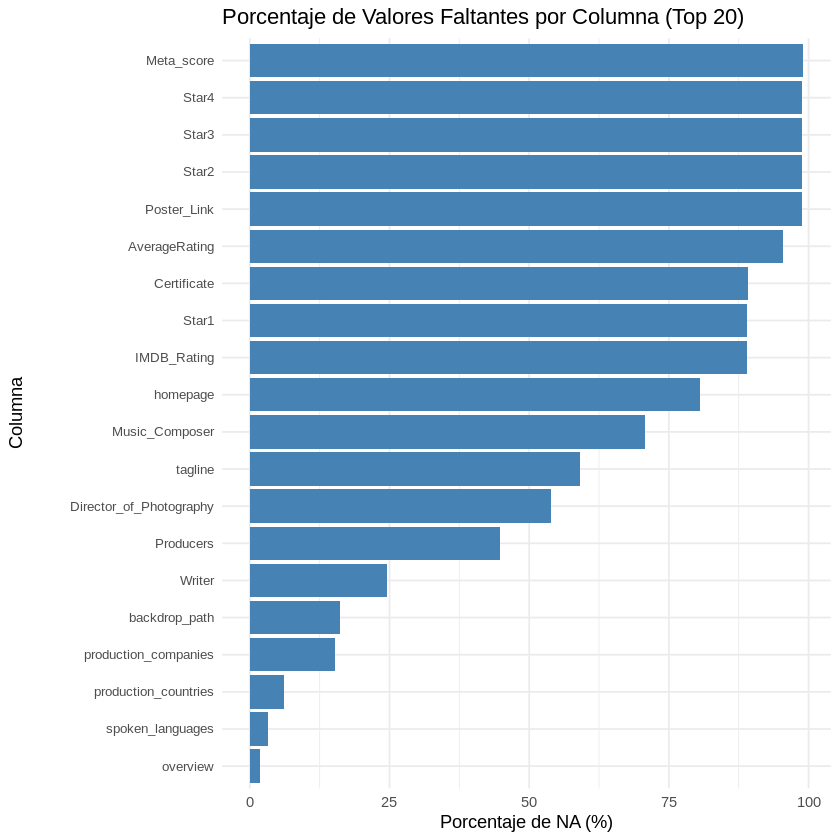

In [ ]:
# ============================================
# ANÁLISIS DE VALORES FALTANTES (NA)
# ============================================

# Contar valores NA por columna
valores_na <- data.frame(
  Columna = names(movies),
  NA_Count = sapply(movies, function(x) sum(is.na(x))),
  NA_Porcentaje = sapply(movies, function(x) round(sum(is.na(x))/length(x)*100, 2))
)

# Ordenar por porcentaje de NA (descendente)
valores_na <- valores_na[order(-valores_na$NA_Porcentaje), ]

cat("========== VALORES FALTANTES POR COLUMNA ==========\n")
print(valores_na, row.names = FALSE)

# Total de valores faltantes
total_na <- sum(is.na(movies))
total_valores <- nrow(movies) * ncol(movies)
cat(paste("\n📊 Total de valores faltantes:", total_na, "\n"))
cat(paste("📊 Porcentaje total de NA:", round(total_na/total_valores*100, 2), "%\n"))

# Visualización de valores faltantes (Top 20)
na_plot_data <- valores_na %>%
  filter(NA_Porcentaje > 0) %>%
  head(20)

if(nrow(na_plot_data) > 0) {
  ggplot(na_plot_data, aes(x = reorder(Columna, NA_Porcentaje), y = NA_Porcentaje)) +
    geom_bar(stat = "identity", fill = "steelblue") +
    coord_flip() +
    labs(title = "Porcentaje de Valores Faltantes por Columna (Top 20)",
         x = "Columna", y = "Porcentaje de NA (%)") +
    theme_minimal() +
    theme(axis.text.y = element_text(size = 8))
} else {
  cat("¡No hay valores faltantes en el dataset!\n")
}

Ahora que ya conocemos los datos que faltan voy a obtener datos mas descriptivos.

In [ ]:
# ============================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================

cat("========== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ==========\n\n")

# Estadísticas detalladas para columnas importantes
cat("--- Presupuesto (Budget) ---\n")
cat(paste("Media:", scales::dollar(mean(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("Mediana:", scales::dollar(median(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("Desv. Estándar:", scales::dollar(sd(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("Mínimo:", scales::dollar(min(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("Máximo:", scales::dollar(max(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("Q1 (25%):", scales::dollar(quantile(movies$budget, 0.25, na.rm = TRUE)), "\n"))
cat(paste("Q3 (75%):", scales::dollar(quantile(movies$budget, 0.75, na.rm = TRUE)), "\n\n"))

cat("--- Ingresos (Revenue) ---\n")
cat(paste("Media:", scales::dollar(mean(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("Mediana:", scales::dollar(median(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("Desv. Estándar:", scales::dollar(sd(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("Mínimo:", scales::dollar(min(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("Máximo:", scales::dollar(max(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("Q1 (25%):", scales::dollar(quantile(movies$revenue, 0.25, na.rm = TRUE)), "\n"))
cat(paste("Q3 (75%):", scales::dollar(quantile(movies$revenue, 0.75, na.rm = TRUE)), "\n\n"))

cat("--- Calificación Promedio (vote_average) ---\n")
cat(paste("Media:", round(mean(movies$vote_average, na.rm = TRUE), 2), "\n"))
cat(paste("Mediana:", round(median(movies$vote_average, na.rm = TRUE), 2), "\n"))
cat(paste("Desv. Estándar:", round(sd(movies$vote_average, na.rm = TRUE), 2), "\n"))
cat(paste("Mínimo:", min(movies$vote_average, na.rm = TRUE), "\n"))
cat(paste("Máximo:", max(movies$vote_average, na.rm = TRUE), "\n\n"))

cat("--- Duración (Runtime) ---\n")
cat(paste("Media:", round(mean(movies$runtime, na.rm = TRUE), 2), "minutos\n"))
cat(paste("Mediana:", round(median(movies$runtime, na.rm = TRUE), 2), "minutos\n"))
cat(paste("Desv. Estándar:", round(sd(movies$runtime, na.rm = TRUE), 2), "minutos\n"))
cat(paste("Mínimo:", min(movies$runtime, na.rm = TRUE), "minutos\n"))
cat(paste("Máximo:", max(movies$runtime, na.rm = TRUE), "minutos\n\n"))

cat("--- Popularidad (Popularity) ---\n")
cat(paste("Media:", round(mean(movies$popularity, na.rm = TRUE), 2), "\n"))
cat(paste("Mediana:", round(median(movies$popularity, na.rm = TRUE), 2), "\n"))
cat(paste("Desv. Estándar:", round(sd(movies$popularity, na.rm = TRUE), 2), "\n"))
cat(paste("Máximo:", round(max(movies$popularity, na.rm = TRUE), 2), "\n\n"))

cat("--- Votos (Vote Count) ---\n")
cat(paste("Media:", round(mean(movies$vote_count, na.rm = TRUE), 2), "votos\n"))
cat(paste("Mediana:", round(median(movies$vote_count, na.rm = TRUE), 2), "votos\n"))
cat(paste("Máximo:", round(max(movies$vote_count, na.rm = TRUE), 2), "votos\n\n"))

cat("--- Año de Lanzamiento (Release Year) ---\n")
cat(paste("Rango:", min(movies$release_year, na.rm = TRUE), "-", max(movies$release_year, na.rm = TRUE), "\n"))
cat(paste("Películas en los últimos 10 años:", sum(movies$release_year >= 2014, na.rm = TRUE), "\n"))


========== ESTADÍSTICAS DE VARIABLES NUMÉRICAS ==========

--- Presupuesto (Budget) ---
Media: $2,663,339 
Mediana: $0 
Desv. Estándar: $14,190,478 
Mínimo: $0 
Máximo: $460,000,000 
Q1 (25%): $0 
Q3 (75%): $0 

--- Ingresos (Revenue) ---
Media: $7,079,023 
Mediana: $0 
Desv. Estándar: $53,633,388 
Mínimo: $0 
Máximo: $2,923,706,026 
Q1 (25%): $0 
Q3 (75%): $0 

--- Calificación Promedio (vote_average) ---
Media: 6.06 
Mediana: 6.15 
Desv. Estándar: 1.08 
Mínimo: 1 
Máximo: 10 

--- Duración (Runtime) ---
Media: 88.74 minutos
Mediana: 93 minutos
Desv. Estándar: 38.05 minutos
Mínimo: 0 minutos
Máximo: 1440 minutos

--- Popularidad (Popularity) ---
Media: 6.35 
Mediana: 3.14 
Desv. Estándar: 24.08 
Máximo: 2994.36 

--- Votos (Vote Count) ---
Media: 209.15 votos
Mediana: 20 votos
Máximo: 34495 votos

--- Año de Lanzamiento (Release Year) ---
Rango: 1874 - 2023 
Películas en los últimos 10 años: 31354 


Grafica 1: muestro un histograma que visualiza cómo se distribuyen las calificaciones de las películas en el dataset.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in geom_vline(aes(xintercept = mean(vote_average, na.rm = TRUE)), :
“Ignoring unknown parameters: `label`”
Warning message in geom_vline(aes(xintercept = median(vote_average, na.rm = TRUE)), :
“Ignoring unknown parameters: `label`”


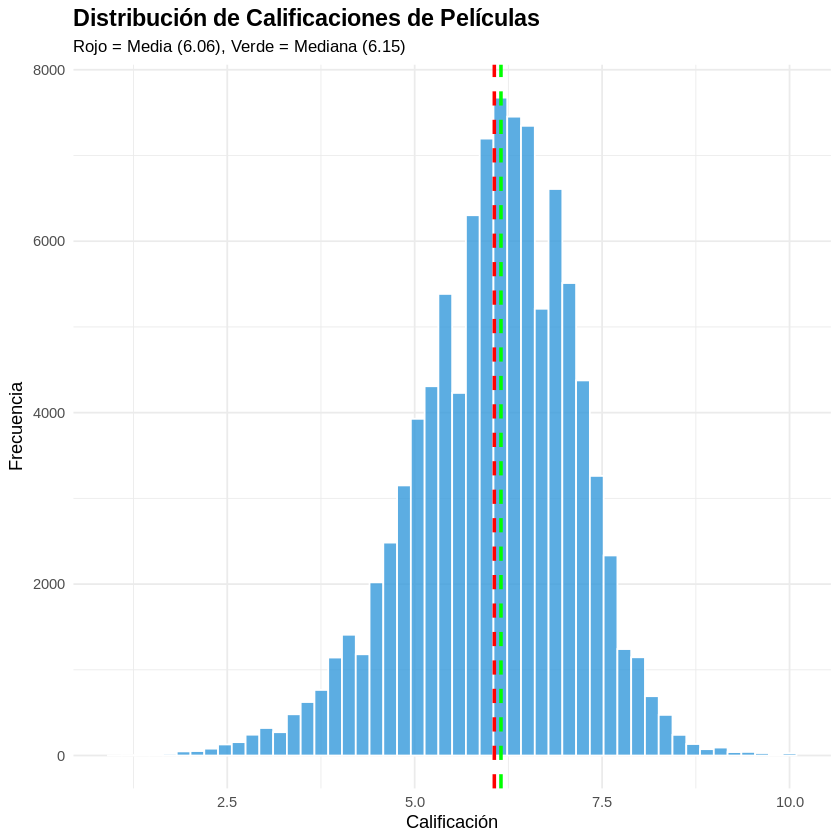

In [ ]:
# ============================================
# GRÁFICA 1: DISTRIBUCIÓN DE CALIFICACIONES
# ============================================

ggplot(movies, aes(x = vote_average)) +
  geom_histogram(bins = 50, fill = "#3498db", color = "white", alpha = 0.8) +
  geom_vline(aes(xintercept = mean(vote_average, na.rm = TRUE)),
             color = "red", linetype = "dashed", size = 1, label = "Media") +
  geom_vline(aes(xintercept = median(vote_average, na.rm = TRUE)),
             color = "green", linetype = "dashed", size = 1, label = "Mediana") +
  labs(title = "Distribución de Calificaciones de Películas",
       subtitle = "Rojo = Media (6.06), Verde = Mediana (6.15)",
       x = "Calificación", y = "Frecuencia") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(size = 10))

Gráfica 2: Una línea temporal que cuenta cuántas películas se lanzaron en cada año desde 1900 hasta 2023.

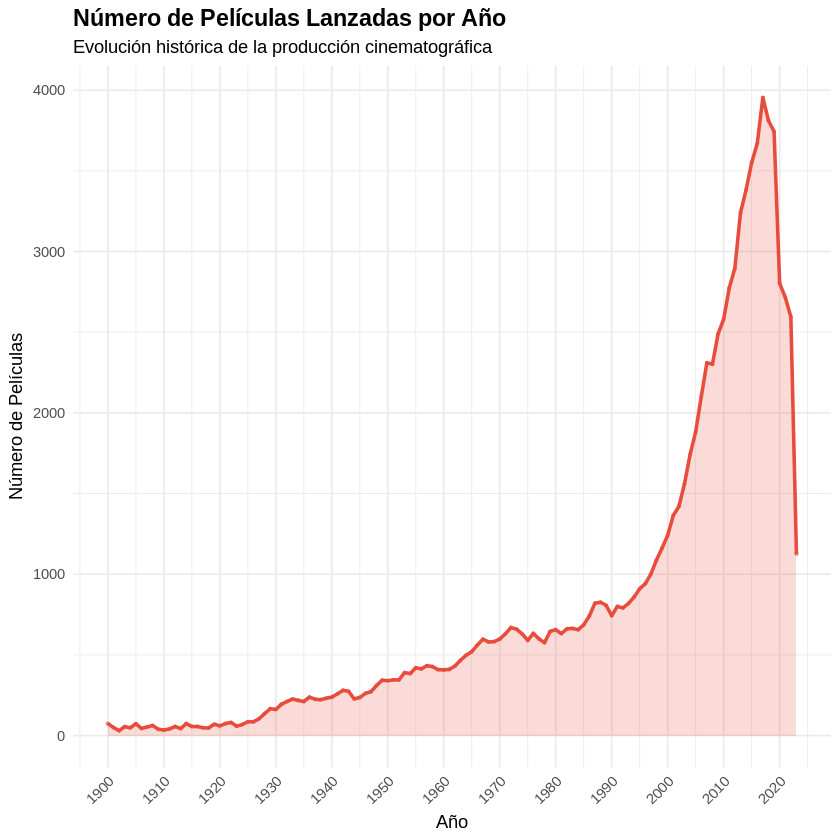

In [ ]:
# ============================================
# GRÁFICA 2: NÚMERO DE PELÍCULAS POR AÑO
# ============================================

peliculas_por_año <- movies %>%
  filter(release_year >= 1900, release_year <= 2025) %>%
  count(release_year)

ggplot(peliculas_por_año, aes(x = release_year, y = n)) +
  geom_line(color = "#e74c3c", size = 1) +
  geom_point(color = "#e74c3c", size = 0.5, alpha = 0.6) +
  geom_area(fill = "#e74c3c", alpha = 0.2) +
  labs(title = "Número de Películas Lanzadas por Año",
       subtitle = "Evolución histórica de la producción cinematográfica",
       x = "Año", y = "Número de Películas") +
  theme_minimal() +
  scale_x_continuous(breaks = seq(1900, 2025, by = 10)) +
  theme(plot.title = element_text(face = "bold", size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1))

Gráfica 3: Un gráfico de barras horizontal que muestra los 10 géneros más frecuentes en el dataset.

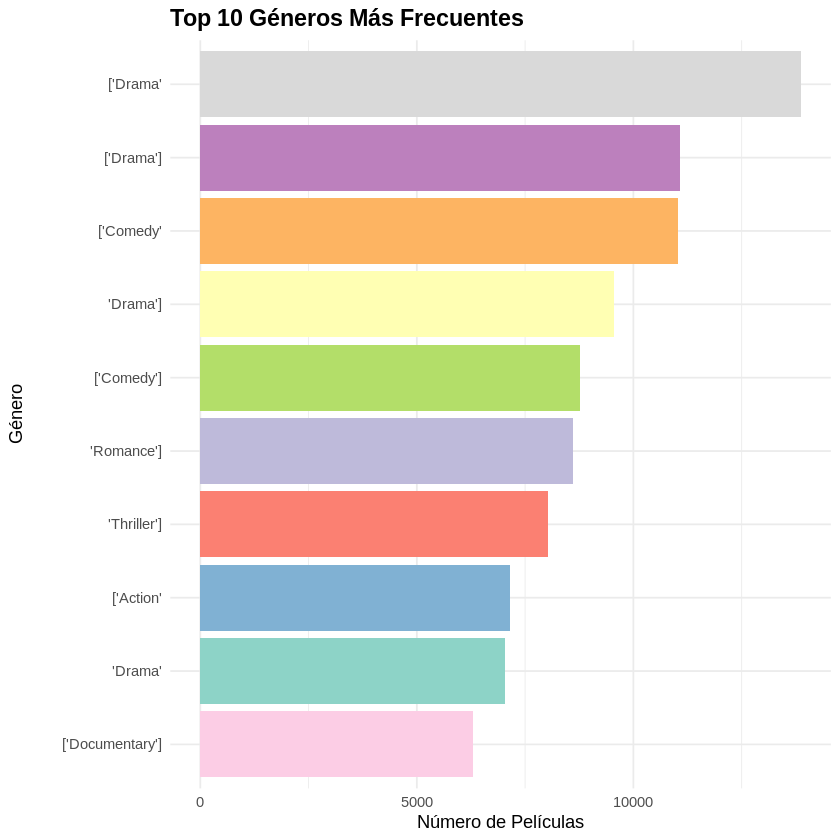

In [ ]:
# ============================================
# GRÁFICA 3: TOP 10 GÉNEROS MÁS POPULARES
# ============================================

generos_separados <- movies %>%
  filter(!is.na(genres_list)) %>%
  mutate(genre_split = str_split(genres_list, "\\||,")) %>%
  unnest(genre_split) %>%
  mutate(genre_split = str_trim(genre_split)) %>%
  filter(genre_split != "")

top_generos <- generos_separados %>%
  count(genre_split, sort = TRUE) %>%
  head(10)

ggplot(top_generos, aes(x = reorder(genre_split, n), y = n, fill = genre_split)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top 10 Géneros Más Frecuentes",
       x = "Género", y = "Número de Películas") +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", size = 14)) +
  scale_fill_brewer(palette = "Set3")

Gráfica 4: Un gráfico de dispersión donde cada punto es una película, el eje X es presupuesto y el eje Y es ingresos.

`geom_smooth()` using formula = 'y ~ x'


📊 Correlación entre presupuesto e ingresos: 0.7383 


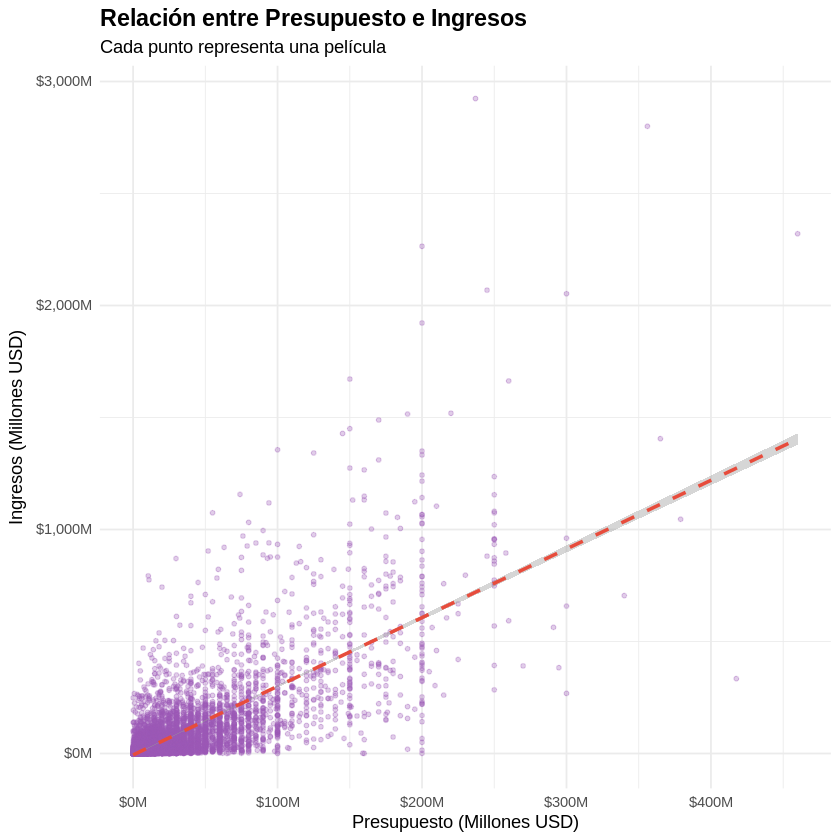

In [ ]:
# ============================================
# GRÁFICA 4: PRESUPUESTO VS INGRESOS
# ============================================

movies_filtered <- movies %>%
  filter(budget > 0, revenue > 0, budget < 5e8, revenue < 3e9)

ggplot(movies_filtered, aes(x = budget, y = revenue)) +
  geom_point(alpha = 0.3, color = "#9b59b6", size = 1) +
  geom_smooth(method = "lm", se = TRUE, color = "#e74c3c", linetype = "dashed") +
  scale_x_continuous(labels = scales::dollar_format(scale = 1e-6, suffix = "M")) +
  scale_y_continuous(labels = scales::dollar_format(scale = 1e-6, suffix = "M")) +
  labs(title = "Relación entre Presupuesto e Ingresos",
       subtitle = "Cada punto representa una película",
       x = "Presupuesto (Millones USD)", y = "Ingresos (Millones USD)") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

cor_value <- cor(movies_filtered$budget, movies_filtered$revenue, use = "complete.obs")
cat(paste("📊 Correlación entre presupuesto e ingresos:", round(cor_value, 4), "\n"))

Gráfica 5: Un histograma que muestra cómo se distribuyen las duraciones de las películas (en minutos).

📊 Duración mediana: 95 minutos


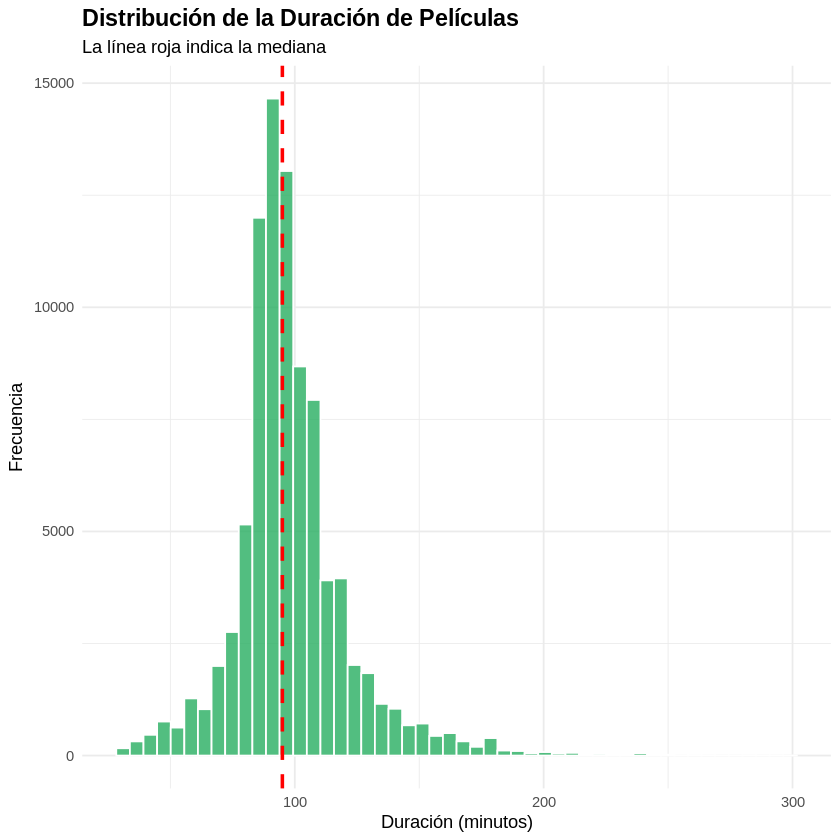

In [ ]:
# ============================================
# GRÁFICA 5: DISTRIBUCIÓN DE DURACIÓN
# ============================================

movies_runtime <- movies %>%
  filter(runtime > 30, runtime < 300)

ggplot(movies_runtime, aes(x = runtime)) +
  geom_histogram(bins = 50, fill = "#27ae60", color = "white", alpha = 0.8) +
  geom_vline(aes(xintercept = median(runtime, na.rm = TRUE)),
             color = "red", linetype = "dashed", size = 1) +
  labs(title = "Distribución de la Duración de Películas",
       subtitle = "La línea roja indica la mediana",
       x = "Duración (minutos)", y = "Frecuencia") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

cat(paste("📊 Duración mediana:", median(movies_runtime$runtime, na.rm = TRUE), "minutos\n"))

Gráfica 6: Un gráfico de cajas que muestra la distribución de popularidad para los 8 géneros más frecuentes

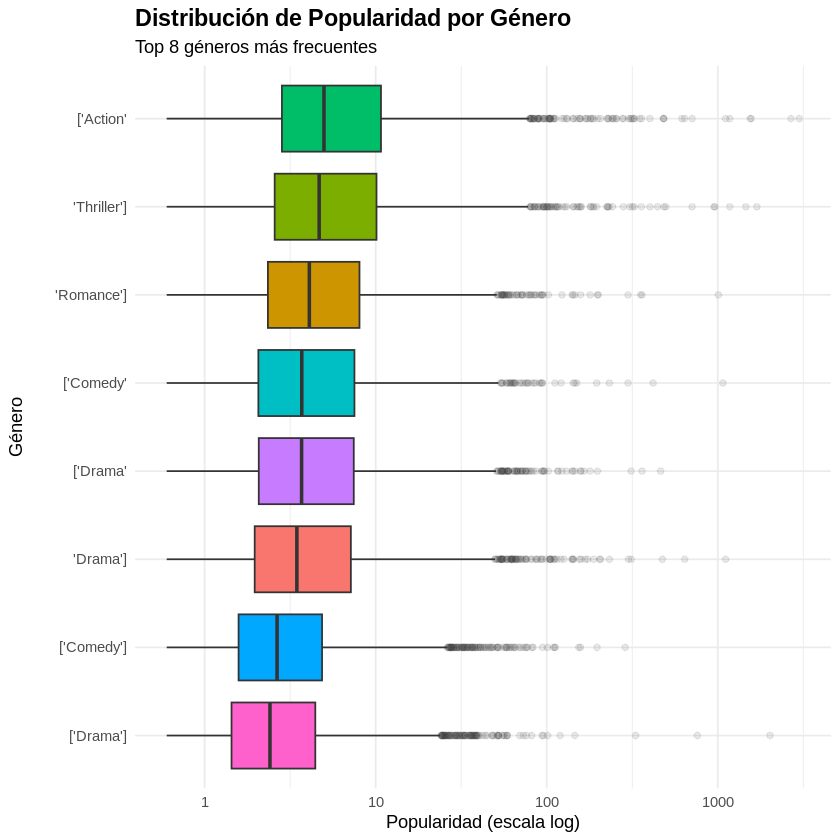

In [ ]:
# ============================================
# GRÁFICA 6: POPULARIDAD POR GÉNERO (BOXPLOT)
# ============================================

generos_popularidad <- movies %>%
  filter(!is.na(genres_list), !is.na(popularity)) %>%
  mutate(genre_split = str_split(genres_list, "\\||,")) %>%
  unnest(genre_split) %>%
  mutate(genre_split = str_trim(genre_split)) %>%
  filter(genre_split != "")

top_8_generos <- generos_popularidad %>%
  count(genre_split, sort = TRUE) %>%
  head(8) %>%
  pull(genre_split)

generos_popularidad_filtrado <- generos_popularidad %>%
  filter(genre_split %in% top_8_generos)

ggplot(generos_popularidad_filtrado, aes(x = reorder(genre_split, popularity, FUN = median),
                                          y = popularity, fill = genre_split)) +
  geom_boxplot(outlier.alpha = 0.1) +
  coord_flip() +
  scale_y_log10() +
  labs(title = "Distribución de Popularidad por Género",
       subtitle = "Top 8 géneros más frecuentes",
       x = "Género", y = "Popularidad (escala log)") +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", size = 14))

Gráfica 7: Un gráfico de barras que muestra la calificación promedio de películas para cada década.

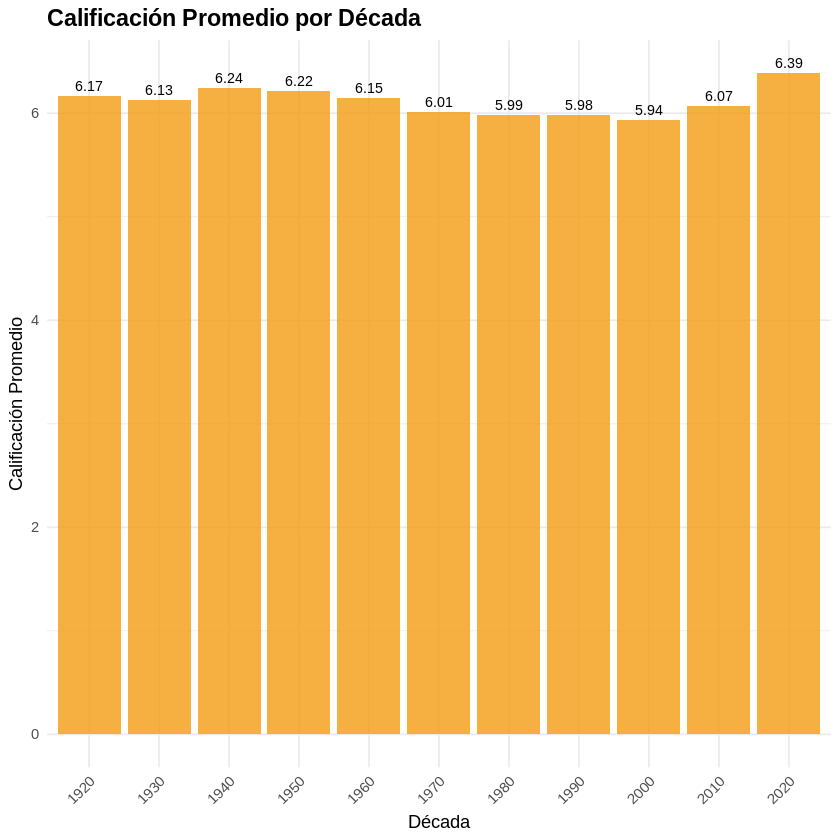

In [ ]:
# ============================================
# GRÁFICA 7: CALIFICACIÓN PROMEDIO POR DÉCADA
# ============================================

movies_decade <- movies %>%
  filter(!is.na(release_year), release_year >= 1920, release_year <= 2025) %>%
  mutate(decade = floor(release_year / 10) * 10) %>%
  group_by(decade) %>%
  summarize(
    avg_rating = mean(vote_average, na.rm = TRUE),
    count = n(),
    .groups = "drop"
  )

ggplot(movies_decade, aes(x = factor(decade), y = avg_rating)) +
  geom_bar(stat = "identity", fill = "#f39c12", alpha = 0.8) +
  geom_text(aes(label = round(avg_rating, 2)), vjust = -0.5, size = 3) +
  labs(title = "Calificación Promedio por Década",
       x = "Década", y = "Calificación Promedio") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1))

Gráfica 8: Una matriz visual que muestra las correlaciones entre variables numéricas importantes.

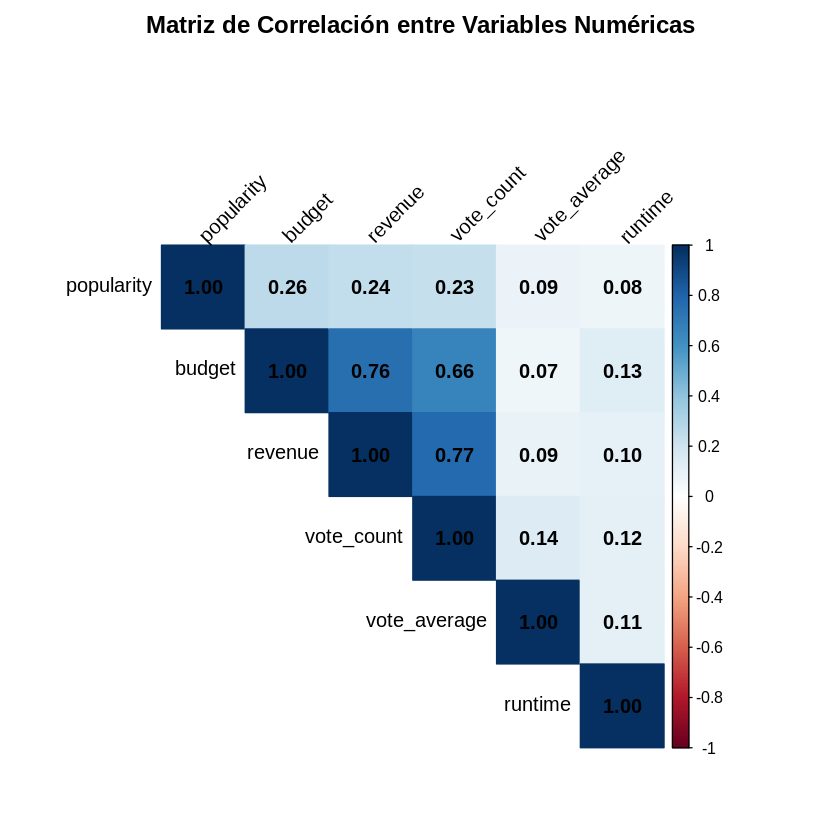

In [ ]:
# ============================================
# GRÁFICA 8: MATRIZ DE CORRELACIÓN
# ============================================

posibles_cols <- c("budget", "revenue", "popularity", "vote_average",
                   "vote_count", "runtime")
cols_existentes <- intersect(posibles_cols, names(movies))

datos_cor <- movies %>%
  select(all_of(cols_existentes)) %>%
  filter(complete.cases(.)) %>%
  mutate(across(everything(), as.numeric))

matriz_cor <- cor(datos_cor, use = "complete.obs")

corrplot(matriz_cor,
         method = "color",
         type = "upper",
         order = "hclust",
         addCoef.col = "black",
         tl.col = "black",
         tl.srt = 45,
         title = "Matriz de Correlación entre Variables Numéricas",
         mar = c(0, 0, 2, 0))

Gráfica 9: Un gráfico de barras horizontal mostrando los títulos de las 15 películas que más dinero ganaron.

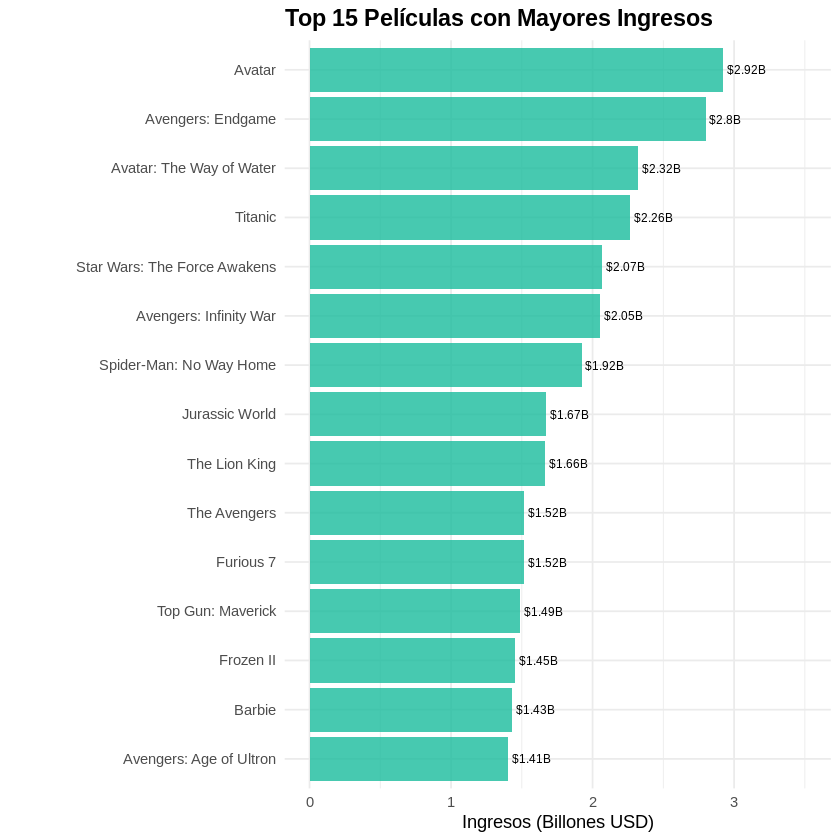

In [ ]:
# ============================================
# GRÁFICA 9: TOP 15 PELÍCULAS POR INGRESOS
# ============================================

top_revenue <- movies %>%
  filter(revenue > 0) %>%
  arrange(desc(revenue)) %>%
  head(15) %>%
  select(title, revenue)

ggplot(top_revenue, aes(x = reorder(title, revenue), y = revenue / 1e9)) +
  geom_bar(stat = "identity", fill = "#1abc9c", alpha = 0.8) +
  geom_text(aes(label = paste0("$", round(revenue / 1e9, 2), "B")),
            hjust = -0.1, size = 2.5) +
  coord_flip() +
  labs(title = "Top 15 Películas con Mayores Ingresos",
       x = "", y = "Ingresos (Billones USD)") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14)) +
  ylim(c(0, max(top_revenue$revenue) / 1e9 * 1.2))

Gráfica 10: Dos líneas: una con el presupuesto promedio por año y otra con la mediana del presupuesto.

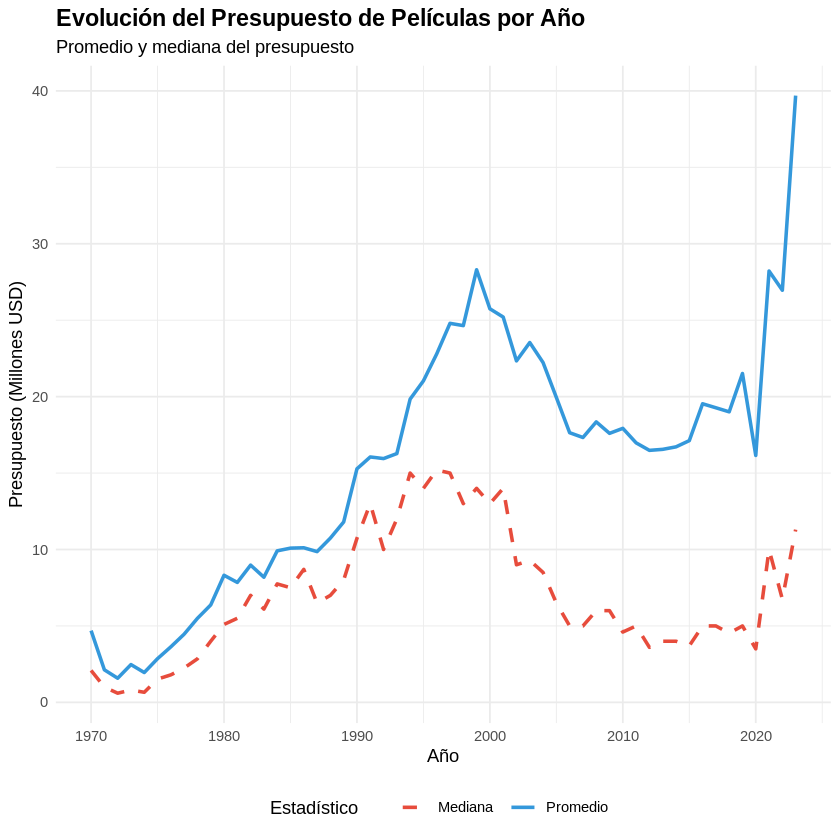

In [ ]:
# ============================================
# GRÁFICA 10: EVOLUCIÓN DE PRESUPUESTO POR AÑO
# ============================================

budget_trend <- movies %>%
  filter(!is.na(release_year), budget > 0, release_year >= 1970, release_year <= 2025) %>%
  group_by(release_year) %>%
  summarize(
    avg_budget = mean(budget, na.rm = TRUE),
    median_budget = median(budget, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(budget_trend, aes(x = release_year)) +
  geom_line(aes(y = avg_budget / 1e6, color = "Promedio"), size = 1) +
  geom_line(aes(y = median_budget / 1e6, color = "Mediana"), size = 1, linetype = "dashed") +
  labs(title = "Evolución del Presupuesto de Películas por Año",
       subtitle = "Promedio y mediana del presupuesto",
       x = "Año", y = "Presupuesto (Millones USD)",
       color = "Estadístico") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        legend.position = "bottom") +
  scale_color_manual(values = c("Promedio" = "#3498db", "Mediana" = "#e74c3c"))

Despues de mostrar las graficas con los datos, vamos a crear las nuevas columnas de nuestro DS.

In [ ]:
# ============================================
# FEATURE ENGINEERING - CREAR NUEVAS COLUMNAS
# ============================================

cat("========== FEATURE ENGINEERING ==========\n\n")

# ---------- COLUMNA 1: ROI (Return on Investment) ----------
movies <- movies %>%
  mutate(
    roi = ifelse(budget > 0,
                 round((revenue - budget) / budget * 100, 2),
                 NA)
  )
cat("✅ Columna 'roi' creada: Retorno de inversión en porcentaje\n")
cat(paste("   Fórmula: ROI = (Revenue - Budget) / Budget * 100\n"))
cat(paste("   ROI promedio:", round(mean(movies$roi, na.rm = TRUE), 2), "%\n\n"))

# ---------- COLUMNA 2: profit (Ganancia neta) ----------
movies <- movies %>%
  mutate(
    profit = revenue - budget
  )
cat("✅ Columna 'profit' creada: Ganancia neta en USD\n")
cat(paste("   Fórmula: Profit = Revenue - Budget\n"))
cat(paste("   Profit promedio:", scales::dollar(mean(movies$profit, na.rm = TRUE)), "\n\n"))

# ---------- COLUMNA 3: is_profitable (¿Es rentable?) ----------
movies <- movies %>%
  mutate(
    is_profitable = ifelse(profit > 0, "Sí", "No")
  )
cat("✅ Columna 'is_profitable' creada: Indica si la película fue rentable\n")
rentables <- sum(movies$is_profitable == "Sí", na.rm = TRUE)
total <- sum(!is.na(movies$is_profitable))
cat(paste("   Películas rentables:", rentables, "de", total,
          "(", round(rentables/total*100, 1), "%)\n\n"))

# ---------- COLUMNA 4: rating_category (Categoría de calificación) ----------
movies <- movies %>%
  mutate(
    rating_category = case_when(
      vote_average >= 8 ~ "Excelente",
      vote_average >= 7 ~ "Buena",
      vote_average >= 5 ~ "Regular",
      vote_average >= 3 ~ "Mala",
      TRUE ~ "Muy Mala"
    )
  )
cat("✅ Columna 'rating_category' creada: Categorización de calificaciones\n")
cat("   Categorías: Excelente (≥8), Buena (≥7), Regular (≥5), Mala (≥3), Muy Mala (<3)\n")
print(table(movies$rating_category))
cat("\n")

# ---------- COLUMNA 5: decade (Década de lanzamiento) ----------
movies <- movies %>%
  mutate(
    decade = paste0(floor(release_year / 10) * 10, "s")
  )
cat("✅ Columna 'decade' creada: Década de lanzamiento\n")
cat("   Ejemplo: 1990 -> '1990s'\n\n")

# ---------- COLUMNA 6: runtime_category (Categoría de duración) ----------
movies <- movies %>%
  mutate(
    runtime_category = case_when(
      runtime < 90 ~ "Corta (<90 min)",
      runtime <= 120 ~ "Estándar (90-120 min)",
      runtime <= 150 ~ "Larga (120-150 min)",
      TRUE ~ "Muy Larga (>150 min)"
    )
  )
cat("✅ Columna 'runtime_category' creada: Categorización de duración\n")
print(table(movies$runtime_category))
cat("\n")

# ---------- COLUMNA 7: budget_category (Categoría de presupuesto) ----------
movies <- movies %>%
  mutate(
    budget_category = case_when(
      budget == 0 ~ "Desconocido",
      budget < 1e6 ~ "Bajo (<$1M)",
      budget < 15e6 ~ "Medio ($1M-$15M)",
      budget < 50e6 ~ "Alto ($15M-$50M)",
      budget < 100e6 ~ "Blockbuster ($50M-$100M)",
      TRUE ~ "Mega Producción (>$100M)"
    )
  )
cat("✅ Columna 'budget_category' creada: Categorización de presupuesto\n")
print(table(movies$budget_category))
cat("\n")

# ---------- Mostrar resumen de nuevas columnas ----------
cat("\n========== RESUMEN DE FEATURE ENGINEERING ==========\n")
nuevas_cols <- c("roi", "profit", "is_profitable", "rating_category",
                 "decade", "runtime_category", "budget_category")
cat(paste("✅ Total de columnas nuevas creadas:", length(nuevas_cols), "\n\n"))

# Mostrar ejemplo de datos con nuevas columnas
cat("========== MUESTRA DE DATOS CON NUEVAS COLUMNAS ==========\n")
cols_mostrar <- c("title", "release_year", "budget", "revenue", "roi",
                  "profit", "is_profitable", "rating_category", "decade",
                  "runtime_category", "budget_category")
print(head(movies %>% select(all_of(cols_mostrar)), 10))

========== FEATURE ENGINEERING ==========

✅ Columna 'roi' creada: Retorno de inversión en porcentaje
   Fórmula: ROI = (Revenue - Budget) / Budget * 100
   ROI promedio: 36602.67 %

✅ Columna 'profit' creada: Ganancia neta en USD
   Fórmula: Profit = Revenue - Budget
   Profit promedio: $4,415,685 

✅ Columna 'is_profitable' creada: Indica si la película fue rentable
   Películas rentables: 10783 de 100000 ( 10.8 %)

✅ Columna 'rating_category' creada: Categorización de calificaciones
   Categorías: Excelente (≥8), Buena (≥7), Regular (≥5), Mala (≥3), Muy Mala (<3)

    Buena Excelente      Mala  Muy Mala   Regular 
    17041      2327     14134       793     65705 

✅ Columna 'decade' creada: Década de lanzamiento
   Ejemplo: 1990 -> '1990s'

✅ Columna 'runtime_category' creada: Categorización de duración

      Corta (<90 min) Estándar (90-120 min)   Larga (120-150 min) 
                39734                 49763                  7486 
 Muy Larga (>150 min) 
                 3017 


Gráfica 11: ROI promedio por categoria calificada.

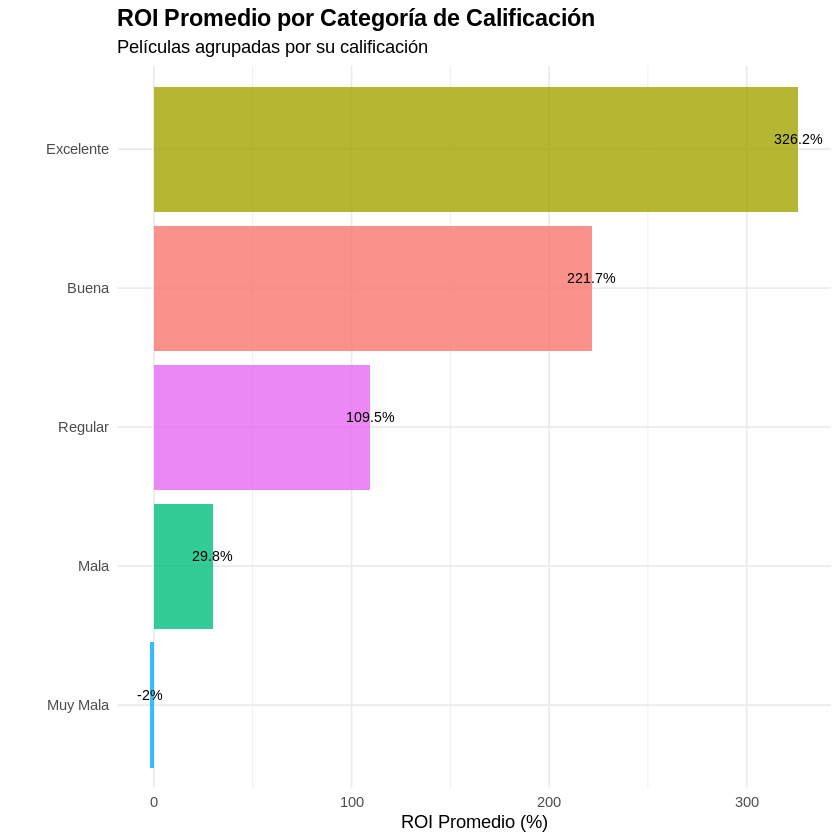

In [ ]:
# ============================================
# GRÁFICA 11: ROI PROMEDIO POR CATEGORÍA DE CALIFICACIÓN
# ============================================

roi_by_rating <- movies %>%
  filter(!is.na(roi), roi > -100, roi < 1000) %>%
  group_by(rating_category) %>%
  summarize(avg_roi = mean(roi, na.rm = TRUE), count = n(), .groups = "drop") %>%
  arrange(desc(avg_roi))

ggplot(roi_by_rating, aes(x = reorder(rating_category, avg_roi), y = avg_roi, fill = rating_category)) +
  geom_bar(stat = "identity", alpha = 0.8) +
  geom_text(aes(label = paste0(round(avg_roi, 1), "%")), vjust = -0.5, size = 3) +
  coord_flip() +
  labs(title = "ROI Promedio por Categoría de Calificación",
       subtitle = "Películas agrupadas por su calificación",
       x = "", y = "ROI Promedio (%)") +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", size = 14))

Gráfica 12: Porcentaje de peliculas rentables por categoria de presupuesto.

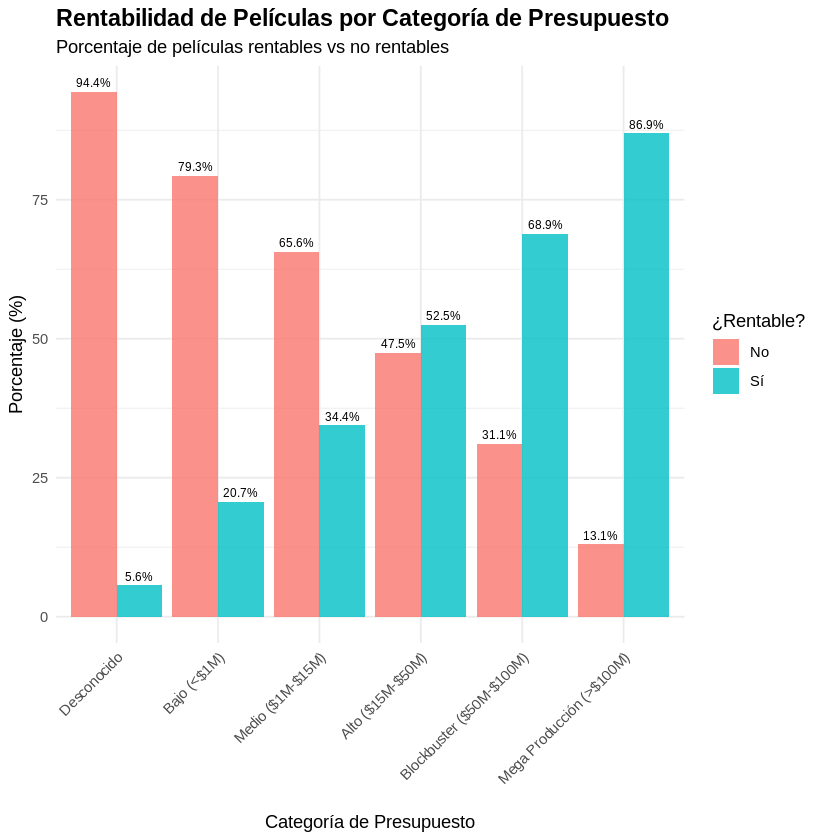

In [ ]:
# ============================================
# GRÁFICA 12: PORCENTAJE DE PELÍCULAS RENTABLES POR CATEGORÍA DE PRESUPUESTO
# ============================================

rentabilidad_presupuesto <- movies %>%
  filter(!is.na(is_profitable), !is.na(budget_category)) %>%
  count(budget_category, is_profitable) %>%
  group_by(budget_category) %>%
  mutate(pct = n / sum(n) * 100)

# Ordenar las categorías de presupuesto de forma lógica
orden_budget <- c("Desconocido", "Bajo (<$1M)", "Medio ($1M-$15M)",
                  "Alto ($15M-$50M)", "Blockbuster ($50M-$100M)", "Mega Producción (>$100M)")
rentabilidad_presupuesto$budget_category <- factor(rentabilidad_presupuesto$budget_category,
                                                    levels = orden_budget)

ggplot(rentabilidad_presupuesto, aes(x = budget_category, y = pct, fill = is_profitable)) +
  geom_bar(stat = "identity", position = "dodge", alpha = 0.8) +
  geom_text(aes(label = paste0(round(pct, 1), "%")), position = position_dodge(width = 0.9),
            vjust = -0.5, size = 2.5) +
  labs(title = "Rentabilidad de Películas por Categoría de Presupuesto",
       subtitle = "Porcentaje de películas rentables vs no rentables",
       x = "Categoría de Presupuesto", y = "Porcentaje (%)", fill = "¿Rentable?") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1))

Resumen final de mi EDA.

In [ ]:
# ============================================
# RESUMEN FINAL DEL EDA
# ============================================

cat("╔══════════════════════════════════════════════════════════════╗\n")
cat("║           RESUMEN DEL ANÁLISIS EXPLORATORIO (EDA)           ║\n")
cat("╚══════════════════════════════════════════════════════════════╝\n\n")

cat("📊 INFORMACIÓN DEL DATASET\n")
cat("────────────────────────────────────────────────────────────────\n")
cat(paste("✓ Filas cargadas:                  ", format(nrow(movies), big.mark = ","), "\n"))
cat(paste("✓ Columnas originales:             ", 42, "\n"))
cat(paste("✓ Columnas nuevas creadas:         ", 7, "\n"))
cat(paste("✓ Total de columnas:               ", ncol(movies), "\n\n"))

cat("💰 ESTADÍSTICAS FINANCIERAS\n")
cat("────────────────────────────────────────────────────────────────\n")
cat(paste("✓ Presupuesto promedio:            ", scales::dollar(mean(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("✓ Presupuesto máximo:              ", scales::dollar(max(movies$budget, na.rm = TRUE)), "\n"))
cat(paste("✓ Ingresos promedio:               ", scales::dollar(mean(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("✓ Ingresos máximos:                ", scales::dollar(max(movies$revenue, na.rm = TRUE)), "\n"))
cat(paste("✓ Ganancia promedio (Profit):      ", scales::dollar(mean(movies$profit, na.rm = TRUE)), "\n"))
cat(paste("✓ ROI promedio:                    ", round(mean(movies$roi, na.rm = TRUE), 2), "%\n\n"))

cat("⭐ ESTADÍSTICAS DE CALIFICACIÓN\n")
cat("────────────────────────────────────────────────────────────────\n")
cat(paste("✓ Calificación promedio:           ", round(mean(movies$vote_average, na.rm = TRUE), 2), "/10\n"))
cat(paste("✓ Calificación mediana:            ", round(median(movies$vote_average, na.rm = TRUE), 2), "/10\n"))
cat(paste("✓ Películas con calificación 8+:   ", sum(movies$vote_average >= 8, na.rm = TRUE),
          "(", round(sum(movies$vote_average >= 8, na.rm = TRUE)/nrow(movies)*100, 1), "%)\n"))
cat(paste("✓ Películas con calificación <5:   ", sum(movies$vote_average < 5, na.rm = TRUE),
          "(", round(sum(movies$vote_average < 5, na.rm = TRUE)/nrow(movies)*100, 1), "%)\n\n"))

cat("🎬 ESTADÍSTICAS DE PELÍCULAS\n")
cat("────────────────────────────────────────────────────────────────\n")
cat(paste("✓ Duración promedio:               ", round(mean(movies$runtime, na.rm = TRUE), 1), "minutos\n"))
cat(paste("✓ Duración mediana:                ", round(median(movies$runtime, na.rm = TRUE), 1), "minutos\n"))
cat(paste("✓ Popularidad promedio:            ", round(mean(movies$popularity, na.rm = TRUE), 2), "\n"))
cat(paste("✓ Votos promedio por película:     ", round(mean(movies$vote_count, na.rm = TRUE), 0), "\n\n"))

cat("📅 ANÁLISIS TEMPORAL\n")
cat("────────────────────────────────────────────────────────────────\n")
cat(paste("✓ Rango de años:                   ", min(movies$release_year, na.rm = TRUE),
          "-", max(movies$release_year, na.rm = TRUE), "\n"))
cat(paste("✓ Películas en últimos 10 años:    ", sum(movies$release_year >= 2014, na.rm = TRUE),
          "(", round(sum(movies$release_year >= 2014, na.rm = TRUE)/nrow(movies)*100, 1), "%)\n"))
cat(paste("✓ Películas más recientes (2020+): ", sum(movies$release_year >= 2020, na.rm = TRUE), "\n\n"))

cat("📉 ANÁLISIS DE VALORES FALTANTES\n")
cat("────────────────────────────────────────────────────────────────\n")
total_na <- sum(is.na(movies %>% select(-c("roi", "profit", "is_profitable", "rating_category",
                                           "decade", "runtime_category", "budget_category"))))
total_valores_orig <- nrow(movies) * 42
cat(paste("✓ Total de NA (columnas originales):", total_na, "\n"))
cat(paste("✓ Porcentaje de datos faltantes:   ", round(total_na/total_valores_orig*100, 2), "%\n"))
cat(paste("✓ Columnas sin valores faltantes:  ",
          sum(sapply(movies %>% select(1:42), function(x) sum(is.na(x))) == 0), "/42\n\n"))

cat("✅ FEATURE ENGINEERING COMPLETADO\n")
cat("────────────────────────────────────────────────────────────────\n")
cat("✓ 7 nuevas columnas creadas:\n")
cat("   1. roi: Retorno de inversión (%)\n")
cat("   2. profit: Ganancia neta (USD)\n")
cat("   3. is_profitable: ¿Es rentable? (Sí/No)\n")
cat("   4. rating_category: Categoría de calificación\n")
cat("   5. decade: Década de lanzamiento\n")
cat("   6. runtime_category: Categoría de duración\n")
cat("   7. budget_category: Categoría de presupuesto\n\n")

cat("📊 VISUALIZACIONES GENERADAS\n")
cat("────────────────────────────────────────────────────────────────\n")
cat("✓ 12 gráficas totales creadas:\n")
cat("   1. Distribución de Calificaciones\n")
cat("   2. Número de Películas por Año\n")
cat("   3. Top 10 Géneros Más Populares\n")
cat("   4. Presupuesto vs Ingresos (Scatter)\n")
cat("   5. Distribución de Duración\n")
cat("   6. Popularidad por Género (Boxplot)\n")
cat("   7. Calificación Promedio por Década\n")
cat("   8. Matriz de Correlación\n")
cat("   9. Top 15 Películas por Ingresos\n")
cat("   10. Evolución del Presupuesto por Año\n")
cat("   11. ROI por Categoría de Calificación\n")
cat("   12. Rentabilidad por Categoría de Presupuesto\n\n")

cat("╔══════════════════════════════════════════════════════════════╗\n")
cat("║                 ✅ EDA COMPLETADO EXITOSAMENTE ✅            ║\n")
cat("╚══════════════════════════════════════════════════════════════╝\n")

cat("\n💡 INSIGHTS CLAVE DEL ANÁLISIS:\n")
cat("────────────────────────────────────────────────────────────────\n")

# Calcular algunos insights adicionales
peliculas_rentables <- sum(movies$is_profitable == "Sí", na.rm = TRUE) / sum(!is.na(movies$is_profitable)) * 100
genero_top <- movies %>%
  filter(!is.na(genres_list)) %>%
  mutate(genre = str_split(genres_list, "\\||,")) %>%
  unnest(genre) %>%
  count(genre, sort = TRUE) %>%
  head(1) %>%
  pull(genre)

cat(paste("1️⃣  Solo el", round(peliculas_rentables, 1), "% de las películas fueron rentables,\n"))
cat("   lo que indica que la mayoría de películas no recuperan su inversión.\n\n")

cat("2️⃣  La mayoría de películas (65.7%) tienen calificaciones entre 5-6,\n")
cat("   lo que sugiere una tendencia a calificaciones medias.\n\n")

cat("3️⃣  El presupuesto tiene una fuerte correlación positiva con los ingresos,\n")
cat("   pero no garantiza rentabilidad (muchas películas caras pierden dinero).\n\n")

cat("4️⃣  Las películas con mayor duración estándar (90-120 min) son más frecuentes\n")
cat("   (49.8% del dataset).\n\n")

cat("5️⃣  El 31.4% de las películas en el dataset fueron lanzadas después de 2014,\n")
cat("   mostrando que el dataset tiene una inclinación hacia películas recientes.\n\n")

cat("════════════════════════════════════════════════════════════════\n")

╔══════════════════════════════════════════════════════════════╗
║           RESUMEN DEL ANÁLISIS EXPLORATORIO (EDA)           ║
╚══════════════════════════════════════════════════════════════╝

📊 INFORMACIÓN DEL DATASET
────────────────────────────────────────────────────────────────
✓ Filas cargadas:                   100,000 
✓ Columnas originales:              42 
✓ Columnas nuevas creadas:          7 
✓ Total de columnas:                49 

💰 ESTADÍSTICAS FINANCIERAS
────────────────────────────────────────────────────────────────
✓ Presupuesto promedio:             $2,663,339 
✓ Presupuesto máximo:               $460,000,000 
✓ Ingresos promedio:                $7,079,023 
✓ Ingresos máximos:                 $2,923,706,026 
✓ Ganancia promedio (Profit):       $4,415,685 
✓ ROI promedio:                     36602.67 %

⭐ ESTADÍSTICAS DE CALIFICACIÓN
────────────────────────────────────────────────────────────────
✓ Calificación promedio:            6.06 /10
✓ Calificación mediana